# Which LDA axes survive lab correction, and which one *is* the lab?

Two embeddings of the **same 269 sessions**, one fit on the design matrix as it comes and
one after every feature is z-scored within its lab:

| | file |
|---|---|
| no correction | `mouse_LDA_5_bins_raw_25_20-09-2026` |
| lab-corrected | `mouse_LDA_5_bins_labzscore_25_20-09-2026` |

If an axis is **behaviour**, the correction should barely touch it and it should reappear
in the corrected run — possibly renumbered, possibly sign-flipped, but recognisably the
same direction. If an axis is **rig or lab**, there is nothing left of it afterwards and it
has no partner.

### Why this is not "compare LD1 with LD1"

Three things break the naive comparison, and each is handled explicitly. The machinery is
in `lda_lab_correction_alignment.py`; this notebook is the analysis.

* **Order.** Components come out ordered by eigenvalue, and the correction changes the
  eigenvalues, so raw LD4 may be corrected LD2. Every raw axis is matched against every
  corrected axis and the best one-to-one assignment is found (Hungarian on |r|).
* **Sign.** An LDA axis and its negative are the same axis. Matching is on |r|; the sign
  is recorded separately and applied before anything is plotted — otherwise the movement
  arrows point backwards for half the axes.
* **Rotation.** Near-tied eigenvalues leave the leading axes free to rotate among
  themselves, so an axis can fail to find a partner while the *subspace* it lives in is
  perfectly preserved. Principal angles are reported next to the pairwise matching; read
  the two together.

**Chance.** With 25 axes on 58 mice, the best of 25! assignments is a large number even
for unrelated data. Every matched |r| is quoted against a null that shuffles mice and
redoes the whole assignment, so a match is only a match if it beats that.

In [1]:
"""
CONFIGURATION -- the two runs being compared, and every threshold below
=======================================================================
Companion module: lda_lab_correction_alignment.py (same folder) holds the loading, the
matching, the subspace measures and the figures, so this notebook stays readable.

To compare a different pair, change the two paths and re-run from here. The 19-09 pair
(`mouse_LDA_5_bins_25_19-09-2026` / `mouse_LDA_5_bins_lab_25_19-09-2026`) is the previous
run of the same comparison and is a useful check that whatever is found is not one fit's
accident.
"""
RAW_FILE = 'clustering/data_files/mouse_LDA_5_bins_raw_25_20-09-2026'
LAB_FILE = 'clustering/data_files/mouse_LDA_5_bins_labzscore_25_20-09-2026'
N_DIMS    = 25      # axes to align; the files carry 25
N_SHOW    = 8       # axes to print in the per-axis tables and to draw scatter panels for
N_PERM    = 2000    # shuffles of the mouse rows, for the chance level of a match
ALPHA     = 0.05
SAVE_FIGS = False   # True writes to paper-individuality/figures/lab_correction/

In [2]:
"""IMPORTS AND PATHS"""
import sys
import pathlib
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.linalg import orthogonal_procrustes

HERE = pathlib.Path.cwd()
if HERE.name != '4_mice':              # tolerate being run from the repo root
    HERE = next(p for p in [HERE, *HERE.parents]
                if (p / 'paper-individuality').exists()) / 'paper-individuality/4_mice'
ROOT = HERE.parent                     # .../paper-individuality

# A long-lived kernel caches modules, so edits to the companion module or to paper_style
# stay invisible until a restart -- reload explicitly, as the other notebooks do.
for _p in (str(HERE), str(ROOT)):
    if _p not in sys.path:
        sys.path.insert(0, _p)
import paper_style as ps
import lda_lab_correction_alignment as la
importlib.reload(ps)
importlib.reload(la)
ps.use('paper')

LDS = [f'LD{k}' for k in range(1, N_DIMS + 1)]
print('paper-individuality at', ROOT)

paper_style: paper mode, spines=lb, font 7 pt, panels 3.4x2.4 in, save 400 dpi
paper-individuality at /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality


## 1. The two embeddings

Both runs cover the same sessions in the same order, so the rows need no alignment beyond
a check. Everything below is computed at the **mouse** level: the embedding is a *mouse*
LDA, sessions of one mouse are not independent, and a correlation across 269 sessions
would count the same animal several times over.

Note the spread: the corrected run is visibly narrower than the raw one. That is a global
scale difference and not what any of this is asking about, so every comparison below is on
z-scored columns.

In [3]:
raw, lab = la.load(RAW_FILE, N_DIMS), la.load(LAB_FILE, N_DIMS)

common = raw.index.intersection(lab.index)
if len(common) != len(raw) or len(common) != len(lab):
    print(f'!! the two runs do not cover the same sessions: raw {len(raw)}, '
          f'corrected {len(lab)}, shared {len(common)} -- using the shared ones')
raw, lab = raw.loc[common], lab.loc[common]
assert (raw.mouse_name.values == lab.mouse_name.values).all(), 'mouse labels disagree'

Mr, Ml = la.mouse_level(raw, LDS), la.mouse_level(lab, LDS)
A, B = Mr[LDS].to_numpy(float), Ml[LDS].to_numpy(float)

print(f'{len(common)} sessions, {len(Mr)} mice, {Mr.lab.nunique()} labs, {N_DIMS} axes')
print(f'sessions per mouse: '
      f'{raw.groupby("mouse_name").size().describe()[["min", "50%", "max"]].to_dict()}')
pd.DataFrame({'SD raw': raw[LDS].std(), 'SD corrected': lab[LDS].std()}).T.iloc[:, :8].round(2)

263 sessions, 57 mice, 10 labs, 25 axes
sessions per mouse: {'min': 3.0, '50%': 4.0, 'max': 16.0}


,LD1,LD2,LD3,LD4,LD5,LD6,LD7,LD8
SD raw,3.56,2.98,2.54,2.65,2.37,2.39,2.03,2.25
SD corrected,2.40,2.33,1.99,1.87,1.82,1.70,1.55,1.50


## 2. Matching the axes

`corr(raw_i, corrected_j)` for all 25 × 25 pairs, then the one-to-one assignment that
maximises the total |r|. Two columns in the table are worth more attention than the r:

* **margin** — how much better the assigned partner is than the best alternative for that
  raw axis. **Negative means the axis was given its second choice**, because another raw
  axis wanted the same partner and wanted it more.
* **chance95** — the 95th percentile of what this same procedure finds in shuffled data at
  that rank. The top match has to clear ≈ 0.5 before it means anything, and the twentieth
  only ≈ 0.25, which is why a bare |r| cannot be read down the column.

In [4]:
C = la.corr_matrix(A, B)
Cdf = la.corr_frame(C, LDS)      # labelled, for the lookups in section 7
rows, cols = la.match(C)
null = la.null_matched_r(A, B, n_perm=N_PERM)

rec = []
for i, j in zip(rows, cols):
    row_abs = np.abs(C[i])
    best_j = int(np.argmax(row_abs))
    alt = float(np.max(np.delete(row_abs, j)))
    rec.append(dict(raw=LDS[i], corrected=LDS[j], r=C[i, j], abs_r=abs(C[i, j]),
                    sign=int(np.sign(C[i, j])), same_index=int(i == j),
                    best_for_raw=LDS[best_j], margin=abs(C[i, j]) - alt,
                    contested=int(best_j != j)))
pairs = pd.DataFrame(rec).sort_values('abs_r', ascending=False).reset_index(drop=True)
pairs['chance_95'] = np.percentile(null, 95, axis=0)
pairs['p_perm'] = [(np.sum(null[:, k] >= pairs.abs_r[k]) + 1) / (N_PERM + 1)
                   for k in range(len(pairs))]

print(f'{"raw":>6s}{"corrected":>12s}{"r":>9s}{"sign":>6s}{"p_perm":>9s}'
      f'{"chance95":>10s}{"margin":>9s}{"same #":>8s}   note')
for row in pairs.itertuples():
    note = '' if not row.contested else f'wanted {row.best_for_raw}, it was taken'
    print(f'{row.raw:>6s}{row.corrected:>12s}{row.r:+9.3f}{row.sign:>6d}'
          f'{row.p_perm:9.4f}{row.chance_95:10.3f}'
          f'{row.margin:+9.3f}{row.same_index:>8d}   {note}')

good, lost = pairs[pairs.p_perm < ALPHA], pairs[pairs.p_perm >= ALPHA]
print(f'\n{len(good)} of {N_DIMS} axes find a partner above chance (p_perm < {ALPHA}); '
      f'{int(pairs.same_index.sum())} keep their number.')
print('no partner at all: ' + ', '.join(sorted(lost.raw, key=lambda s: int(s[2:]))))
n_cont = int(pairs.contested.sum())
print(f'\n{n_cont} of {N_DIMS} pairings are CONTESTED -- the raw axis correlates more '
      f'strongly with a\ncorrected axis that another raw axis was given. A contested '
      f'pairing with a small\nmargin is a suggestion, not an identification.')

   raw   corrected        r  sign   p_perm  chance95   margin  same #   note
   LD1         LD1   +0.681     1   0.0005     0.498   +0.485       1   
  LD24        LD24   +0.578     1   0.0005     0.445   +0.349       1   
   LD9         LD5   -0.558    -1   0.0005     0.414   +0.282       0   
   LD7         LD3   -0.528    -1   0.0005     0.395   +0.185       0   
  LD25        LD22   +0.519     1   0.0005     0.378   +0.186       0   
   LD5         LD4   +0.515     1   0.0005     0.367   +0.268       0   
  LD19        LD15   -0.504    -1   0.0005     0.355   +0.177       0   
   LD3         LD6   +0.499     1   0.0005     0.345   +0.012       0   
   LD8         LD2   +0.474     1   0.0005     0.335   +0.078       0   
  LD12        LD10   -0.466    -1   0.0005     0.327   +0.104       0   
   LD6         LD7   +0.430     1   0.0005     0.319   +0.146       0   
  LD14        LD11   -0.399    -1   0.0005     0.312   +0.093       0   
  LD20        LD13   -0.396    -1   0.0005     

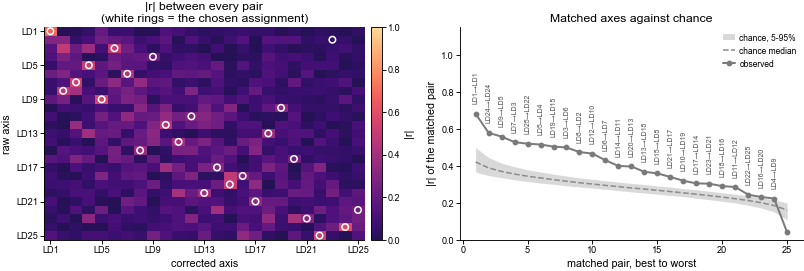

In [5]:
la.fig_match(C, rows, cols, null, pairs, save=SAVE_FIGS)

## 3. Renumbering, or rotation?

A failed match has two very different explanations. Either the direction is gone, or it
survives as a *mixture* of corrected axes and no single one of them looks like it. Pairwise
|r| cannot tell those apart; the principal angles between the leading-k subspaces can.

`mean cos²` of the principal angles is 1 when the two leading-k subspaces are the same and
0 when they are orthogonal. The orthogonal Procrustes rotation adds the complementary view:
its mean largest coefficient per axis would be 1.00 if every raw axis mapped cleanly onto
one corrected axis, and falls as the axes become mixtures of each other.

In [6]:
ks = np.arange(1, N_DIMS + 1)
ov = la.subspace_overlap(A, B, ks)
R, _ = orthogonal_procrustes(la.zscore(A), la.zscore(B))

print('mean cos² of the principal angles, leading k axes:')
print('  ' + '  '.join(f'k={k}:{v:.2f}' for k, v in zip(ks, ov) if k <= 10))
print(f'  k={N_DIMS}: {ov[-1]:.2f}   <- even the FULL 25-dimensional subspaces are only '
      f'partly shared')
print(f'\nbest orthogonal rotation raw -> corrected: '
      f'mean |largest coefficient| per axis = {np.abs(R).max(axis=1).mean():.2f}')
print('(1.00 = every raw axis maps onto exactly one corrected axis; lower means the axes '
      'are\n mixtures of one another, i.e. a rotation inside the subspace rather than a '
      'renumbering)')

mean cos² of the principal angles, leading k axes:
  k=1:0.46  k=2:0.32  k=3:0.32  k=4:0.30  k=5:0.34  k=6:0.38  k=7:0.44  k=8:0.48  k=9:0.50  k=10:0.49
  k=25: 0.66   <- even the FULL 25-dimensional subspaces are only partly shared

best orthogonal rotation raw -> corrected: mean |largest coefficient| per axis = 0.51
(1.00 = every raw axis maps onto exactly one corrected axis; lower means the axes are
 mixtures of one another, i.e. a rotation inside the subspace rather than a renumbering)


## 4. What the correction actually removed

η² is the fraction of an axis's variance across mice that a lab label explains — the
quantity the correction exists to remove.

**Read the raw column, not the corrected one.** Z-scoring each feature within its lab sets
every lab mean to exactly zero, and a linear projection of zeros is zero, so the corrected
column *cannot* come out as anything but 0.000. That is arithmetic, not evidence that the
correction worked. The informative number is how much of each raw axis was lab to begin
with.

It also means the correction removes any genuine between-lab difference in **behaviour**
along with the rig differences. Nothing in this notebook can separate those two.

In [7]:
eta_raw, eta_lab = la.lab_eta2(Mr, LDS), la.lab_eta2(Ml, LDS)

print(f'{"axis":>6s}{"eta2 raw":>11s}{"p":>9s}{"eta2 corr":>12s}{"change":>10s}')
for ld in LDS[:N_SHOW]:
    a, b = eta_raw.loc[ld], eta_lab.loc[ld]
    print(f'{ld:>6s}{a.eta2:11.3f}{a.p:9.3f}{b.eta2:12.3f}{b.eta2 - a.eta2:+10.3f}')
print(f'\nmean over all {N_DIMS} axes: {eta_raw.eta2.mean():.3f} raw -> '
      f'{eta_lab.eta2.mean():.3f} corrected')
if np.allclose(eta_lab.eta2.to_numpy(float), 0, atol=1e-9):
    print('(the corrected column is exactly zero on every axis -- by construction, as above)')

most_lab = eta_raw.eta2.sort_values(ascending=False)
print('\nmost lab-loaded raw axes: '
      + ', '.join(f'{k} {v:.2f}' for k, v in most_lab.head(4).items()))
print('least lab-loaded raw axes: '
      + ', '.join(f'{k} {v:.2f}' for k, v in most_lab.tail(4).items()))

  axis   eta2 raw        p   eta2 corr    change
   LD1      0.415    0.001       0.000    -0.415
   LD2      0.480    0.000       0.000    -0.480
   LD3      0.122    0.683      -0.000    -0.122
   LD4      0.509    0.000       0.000    -0.509
   LD5      0.286    0.050       0.000    -0.286
   LD6      0.362    0.007      -0.000    -0.362
   LD7      0.095    0.830       0.000    -0.095
   LD8      0.163    0.442       0.000    -0.163

mean over all 25 axes: 0.203 raw -> 0.000 corrected
(the corrected column is exactly zero on every axis -- by construction, as above)

most lab-loaded raw axes: LD4 0.51, LD2 0.48, LD1 0.42, LD6 0.36
least lab-loaded raw axes: LD16 0.10, LD7 0.10, LD12 0.10, LD17 0.06


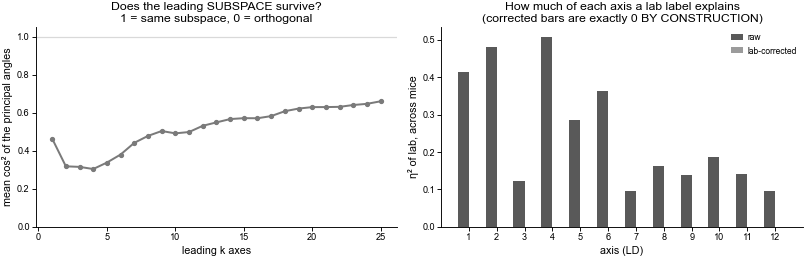

In [8]:
la.fig_structure(ks, ov, eta_raw, eta_lab, LDS, save=SAVE_FIGS)

## 5. The matched pairs, one by one

One point per mouse, coloured by lab, raw axis against its partner. The corrected axis is
sign-flipped onto the raw one where the match was negative, and the panel says so.

What to look for: a pair that is genuinely the same direction gives a tight line with the
labs mixed through it. A pair held together by lab structure instead gives a line built out
of separated lab clusters — the correlation is then between lab means, not between mice.

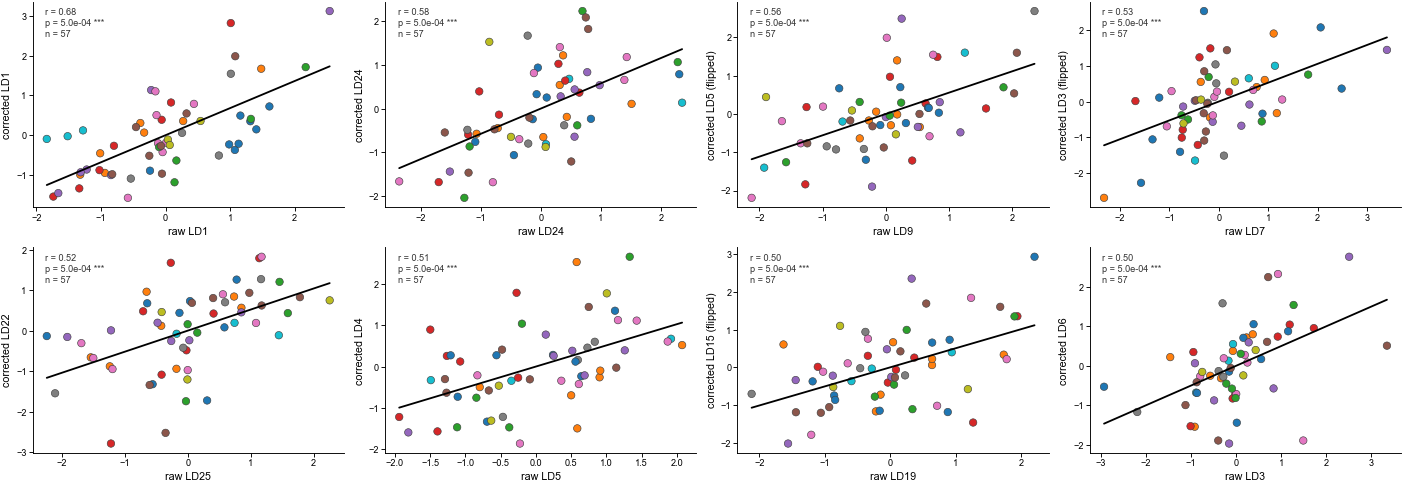

In [9]:
la.fig_pairs(Mr, Ml, pairs, N_SHOW, save=SAVE_FIGS)

## 6. How two matched dimensions move as the correction is applied

The plane of two matched axes, one point per mouse, before and after. Both runs are
z-scored and the corrected axes are sign-flipped onto their partners first, so an arrow is
a change of **position**, not a change of units or of an arbitrary sign.

Four panels: where the mice sit before, where they sit after, every mouse's displacement,
and the lab centroids on their own. The last panel earns its place — the mouse arrows are
long and mostly report the *rotation* between the two axis systems, which otherwise buries
the part that is actually the lab correction: the centroids collapsing onto the origin.

**Two planes, because one is misleading on its own.** The best-matched axes turn out to be
the ones a lab label barely touches, so their panel is nearly all rotation and almost no
collapse. The second plane takes the two most lab-loaded axes that still have a partner,
which is where the correction is visible. The printed numbers under each figure make the
comparison quantitative: if a typical *mouse* moves much further than a lab *centroid*,
most of what you are looking at is rotation, not correction.

LD1 -> LD1   and   LD24 -> LD24    [best-matched axes]
lab eta2 of these raw axes: LD1 0.415, LD24 0.120


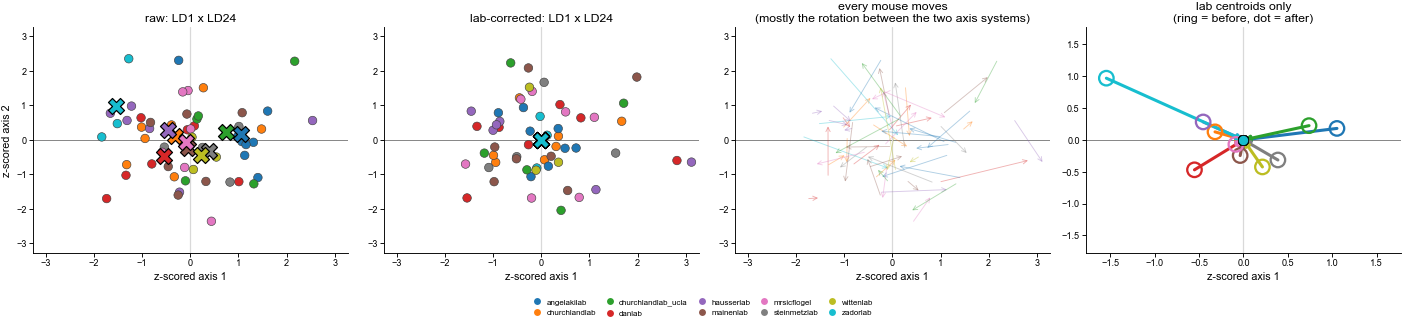

  mouse displacement in this plane: median 1.05 SD, max 2.62 SD
  mean squared distance of a lab centroid from the origin: 0.655 raw -> 0.000 corrected
  median displacement of a lab centroid: 0.52 SD  -- compare with the 1.05 SD a typical MOUSE moves: if the mouse
     number is much the larger, most of the movement is the rotation between
     the two axis systems and not the lab correction.
LD4 -> LD9   and   LD1 -> LD1    [most lab-loaded axes that still have a partner]
lab eta2 of these raw axes: LD4 0.509, LD1 0.415


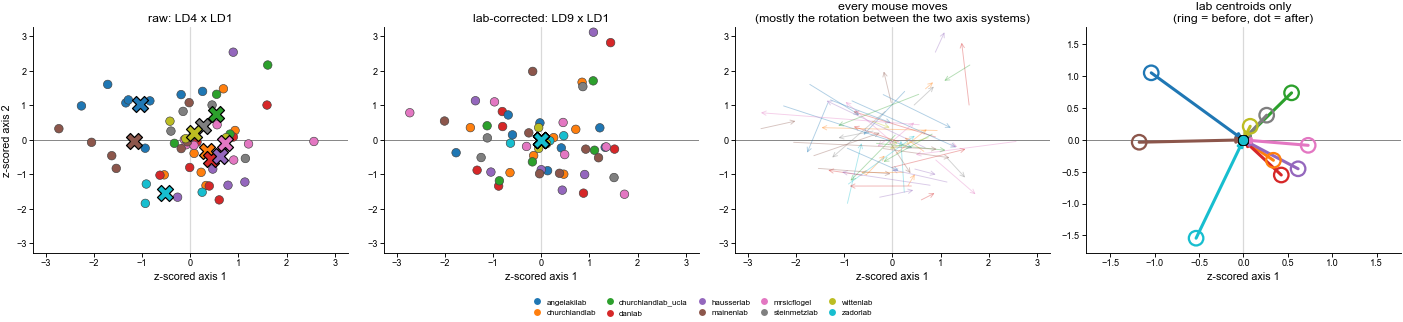

  mouse displacement in this plane: median 1.29 SD, max 3.31 SD
  mean squared distance of a lab centroid from the origin: 0.918 raw -> 0.000 corrected
  median displacement of a lab centroid: 0.75 SD  -- compare with the 1.29 SD a typical MOUSE moves: if the mouse
     number is much the larger, most of the movement is the rotation between
     the two axis systems and not the lab correction.


In [10]:
"""Pick the two planes, then draw each. Set PAIR_REQUEST = (1, 3) to force a plane."""
PAIR_REQUEST = None          # e.g. (1, 3) -> the partners of raw LD1 and raw LD3

Mrz, Mlz = Mr.copy(), Ml.copy()
Mrz[LDS], Mlz[LDS] = la.zscore(A), la.zscore(B)

if PAIR_REQUEST:
    want = [f'LD{k}' for k in PAIR_REQUEST]
    sel = [pairs[pairs.raw == w].iloc[0] for w in want if (pairs.raw == w).any()]
    assert len(sel) == 2, f'{want} are not both raw axes'
    planes = [('the pair asked for', sel)]
else:
    best = [pairs.iloc[0], pairs.iloc[1]]
    survivors = pairs[pairs.p_perm < ALPHA]
    labby = (survivors.assign(eta=[eta_raw.eta2[r] for r in survivors.raw])
             .sort_values('eta', ascending=False))
    planes = [('best-matched axes', best)]
    if len(labby) >= 2 and {labby.iloc[0].raw, labby.iloc[1].raw} != {best[0].raw, best[1].raw}:
        planes.append(('most lab-loaded axes that still have a partner',
                       [labby.iloc[0], labby.iloc[1]]))

for why, sel in planes:
    print('=' * 78)
    print(f'{sel[0].raw} -> {sel[0].corrected}   and   {sel[1].raw} -> {sel[1].corrected}'
          f'    [{why}]')
    print(f'lab eta2 of these raw axes: {sel[0].raw} {eta_raw.eta2[sel[0].raw]:.3f}, '
          f'{sel[1].raw} {eta_raw.eta2[sel[1].raw]:.3f}')
    print('=' * 78)
    la.fig_movement(Mrz, Mlz,
                    [(sel[0].raw, sel[0].corrected, sel[0].sign),
                     (sel[1].raw, sel[1].corrected, sel[1].sign)], save=SAVE_FIGS)

## 7. Correlating specific dimensions

The assignment in section 2 answers one question — *what is the best one-to-one pairing of
all 25 axes at once* — and it answers it globally, which means an individual axis can be
handed a partner it did not want because another axis wanted that partner more. Nine of the
pairings are like that. So there needs to be a way to ask the other question directly: **is
raw LD*i* related to corrected LD*j*?**

`Cdf` is the whole matrix with labels, so any single pair is a lookup, and `la.pair_report`
adds the context that makes one number readable:

* **rank_in_row** — where this corrected axis sits among all 25 partners for that raw axis.
  Rank 1 means you have asked about its favourite; rank 9 means the correlation, however
  large, is one of many.
* **best_in_row / best_in_col** — what each of the two axes actually resembles most. A pair
  can be the raw axis's first choice without being mutual.
* **p** — two-sided, from r and n = 58 mice. **It is honest only if you named the pair
  before looking.** Pick a pair off the heatmap and that p is the p-value of a maximum
  wearing the clothes of a single test; the rank columns are printed next to it so this is
  visible rather than buried.

Rows of `Cdf` are raw axes and columns are corrected ones, so `Cdf.loc['LD3', 'LD2']` and
`Cdf.loc['LD2', 'LD3']` are different numbers.

In [11]:
"""Any single pair is now a lookup; the profile of a whole axis is one line too."""
print('raw LD3 vs corrected LD2:   r = %+.3f' % Cdf.loc['LD3', 'LD2'])
print('raw LD2 vs corrected LD3:   r = %+.3f   <- not the same number' % Cdf.loc['LD2', 'LD3'])

print('\nwhat raw LD3 most resembles in the corrected run:')
print(Cdf.loc['LD3'].abs().nlargest(5).round(3).to_string())

print('\nthe top-left corner of the full matrix:')
display(Cdf.iloc[:8, :8].round(2))

raw LD3 vs corrected LD2:   r = +0.487
raw LD2 vs corrected LD3:   r = -0.048   <- not the same number

what raw LD3 most resembles in the corrected run:
corrected
LD6    0.499
LD2    0.487
LD4    0.372
LD7    0.235
LD3    0.219

the top-left corner of the full matrix:


corrected,LD1,LD2,LD3,LD4,LD5,LD6,LD7,LD8
raw,,,,,,,,
LD1,0.68,0.01,0.01,0.05,-0.20,-0.07,0.07,-0.01
LD2,0.29,0.30,-0.05,0.11,0.23,-0.20,-0.16,0.07
LD3,0.15,0.49,0.22,-0.37,0.09,0.50,0.24,-0.11
LD4,0.13,0.27,0.17,-0.02,-0.03,-0.22,-0.18,0.20
LD5,-0.05,0.19,0.19,0.51,-0.18,0.25,0.17,-0.16
LD6,0.22,-0.28,-0.15,-0.11,-0.17,0.02,0.43,0.05
LD7,-0.06,0.13,-0.53,-0.05,-0.22,0.32,-0.16,0.34
LD8,0.06,0.47,-0.40,0.10,0.07,-0.19,0.26,-0.17


In [12]:
"""
ASK ABOUT SPECIFIC PAIRS
========================
Edit QUERY_PAIRS. Either (3, 6) or ('LD3', 'LD6'); the first entry is always the RAW axis.
The four below are chosen to make the reading clear rather than to be a result:

  (3, 6)  what the global assignment gave raw LD3
  (3, 2)  what raw LD3 actually preferred -- corrected LD2, which raw LD2 was given
  (1, 1)  the same-number pair, which is the comparison one would make by default
  (4, 2)  raw LD4: the most lab-loaded axis of all, and one that found no partner
"""
QUERY_PAIRS = [(3, 6), (3, 2), (1, 1), (4, 2)]

report = la.pair_report(C, LDS, QUERY_PAIRS, n_mice=len(Mr))
print(f'{"raw":>5s}{"corrected":>11s}{"r":>9s}{"p":>10s}{"rank in row":>13s}'
      f'{"its favourite":>16s}{"rank in col":>13s}')
for row in report.itertuples():
    print(f'{row.raw:>5s}{row.corrected:>11s}{row.r:+9.3f}{row.p:10.2e}'
          f'{row.rank_in_row:>13d}{row.best_in_row + f" ({row.r_best_in_row:.2f})":>16s}'
          f'{row.rank_in_col:>13d}')
print(f'\n(n = {len(Mr)} mice; rank 1 of {N_DIMS} means you asked about that axis\'s '
      f'favourite partner)')

  raw  corrected        r         p  rank in row   its favourite  rank in col
  LD3        LD6   +0.499  7.81e-05            1      LD6 (0.50)            1
  LD3        LD2   +0.487  1.24e-04            2      LD6 (0.50)            1
  LD1        LD1   +0.681  5.55e-09            1      LD1 (0.68)            1
  LD4        LD2   +0.269  4.33e-02            1      LD2 (0.27)            5

(n = 57 mice; rank 1 of 25 means you asked about that axis's favourite partner)


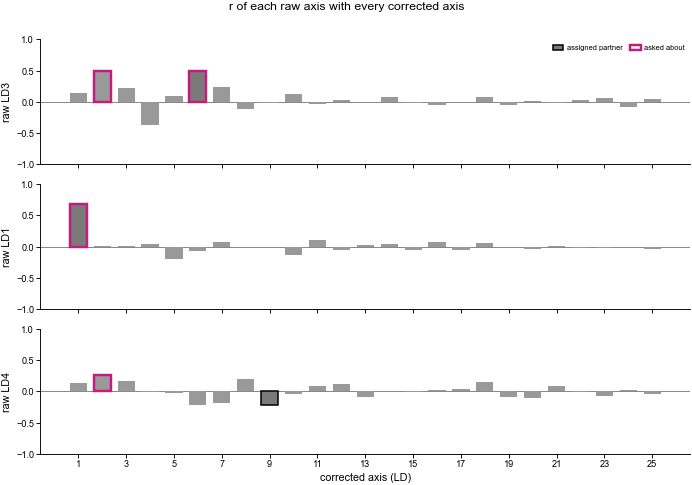

In [13]:
"""One panel per raw axis asked about: what it looks like across ALL corrected axes."""
marks = {}
for a, b in QUERY_PAIRS:
    key = a if isinstance(a, str) else f'LD{a}'
    marks.setdefault(key, []).append(b)

la.fig_pair_profile(C, LDS, list(marks), assigned=pairs, mark=marks, save=SAVE_FIGS)

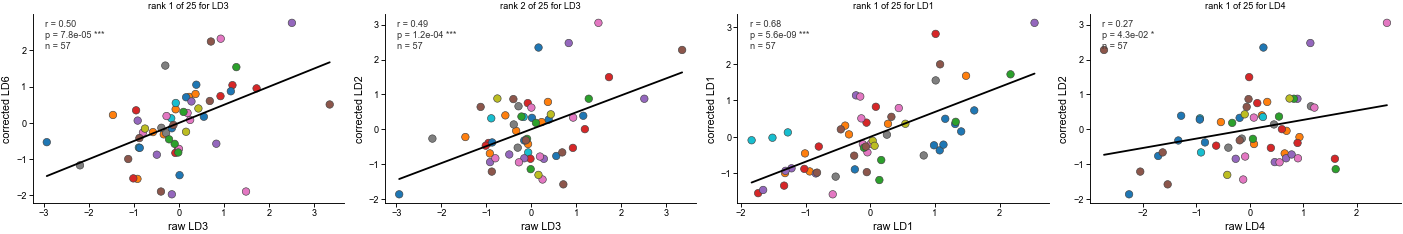

In [14]:
la.fig_specific_pairs(Mr, Ml, report, n_axes=N_DIMS, save=SAVE_FIGS)

## 8. Summary

In [15]:
print('=' * 78)
print('WHICH LDA AXES SURVIVE LAB CORRECTION?')
print('=' * 78)
print(f'raw        {RAW_FILE.split("/")[-1]}')
print(f'corrected  {LAB_FILE.split("/")[-1]}')
print(f'{len(common)} sessions, {len(Mr)} mice, {Mr.lab.nunique()} labs, {N_DIMS} axes, '
      f'matched at the mouse level\n')

print(f'{len(good)} of {N_DIMS} axes find an above-chance partner, '
      f'{int(pairs.same_index.sum())} keep their number, '
      f'{int(pairs.contested.sum())} pairings are contested.')
print('  strongest: ' + ', '.join(f'{r.raw}->{r.corrected} ({r.r:+.2f})'
                                  for r in pairs.head(5).itertuples()))
print('  no partner: ' + ', '.join(sorted(lost.raw, key=lambda s: int(s[2:]))))
print(f'  but the best match is only {pairs.abs_r.iloc[0]:.2f} against a chance 95th of '
      f'{pairs.chance_95.iloc[0]:.2f}, and most\n  survivors sit at 0.3-0.5 against 0.25-0.35. '
      f'These are above chance, not identifications.')

print(f'\nThe SUBSPACE does not survive either: mean cos2 = {ov[0]:.2f} at k=1, '
      f'{ov[4]:.2f} at k=5, {ov[-1]:.2f}\nacross all {N_DIMS}. The best orthogonal rotation '
      f'has a mean largest coefficient of\n{np.abs(R).max(axis=1).mean():.2f}, so each '
      f'corrected axis is a MIXTURE of raw ones. The correction rotates\nthe space; it does '
      f'not merely renumber it.')

print(f'\nHow much of each raw axis was lab: '
      + ', '.join(f'{k} {v:.2f}' for k, v in eta_raw.eta2.sort_values(ascending=False).head(4).items())
      + f'\nagainst ' + ', '.join(f'{k} {v:.2f}' for k, v in
                                  eta_raw.eta2.sort_values().head(3).items()) + '.')
print('The corrected side is zero by construction and carries no information; the '
      'correction also\nremoves any real between-lab difference in behaviour, which this '
      'cannot distinguish from rig.')

# the pairings as a table, so the rest of the repo can read them without re-running this
OUT_CSV = HERE / 'lda_lab_correction_alignment.csv'
pairs.to_csv(OUT_CSV, index=False)
print(f'\nwrote {OUT_CSV.relative_to(ROOT)}')

WHICH LDA AXES SURVIVE LAB CORRECTION?
raw        mouse_LDA_5_bins_raw_25_20-09-2026
corrected  mouse_LDA_5_bins_labzscore_25_20-09-2026
263 sessions, 57 mice, 10 labs, 25 axes, matched at the mouse level

24 of 25 axes find an above-chance partner, 2 keep their number, 10 pairings are contested.
  strongest: LD1->LD1 (+0.68), LD24->LD24 (+0.58), LD9->LD5 (-0.56), LD7->LD3 (-0.53), LD25->LD22 (+0.52)
  no partner: LD2
  but the best match is only 0.68 against a chance 95th of 0.50, and most
  survivors sit at 0.3-0.5 against 0.25-0.35. These are above chance, not identifications.

The SUBSPACE does not survive either: mean cos2 = 0.46 at k=1, 0.34 at k=5, 0.66
across all 25. The best orthogonal rotation has a mean largest coefficient of
0.51, so each corrected axis is a MIXTURE of raw ones. The correction rotates
the space; it does not merely renumber it.

How much of each raw axis was lab: LD4 0.51, LD2 0.48, LD1 0.42, LD6 0.36
against LD17 0.06, LD12 0.10, LD7 0.10.
The corrected sid